Dataset Loaded Successfully
Dataset Shape: (2514, 221)
Number of Diseases: 101
Training Samples: 2011
Testing Samples: 503
Logistic Accuracy: 0.9920477137176938
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         2
           1       1.00      1.00      1.00         6
           2       1.00      1.00      1.00         6
           3       1.00      1.00      1.00         6
           4       1.00      1.00      1.00         4
           5       1.00      1.00      1.00         9
           6       1.00      1.00      1.00         6
           7       1.00      1.00      1.00         4
           8       1.00      1.00      1.00         3
           9       1.00      1.00      1.00         6
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         6
          13       1.00      1.00      1.00         7
          14       1.00     

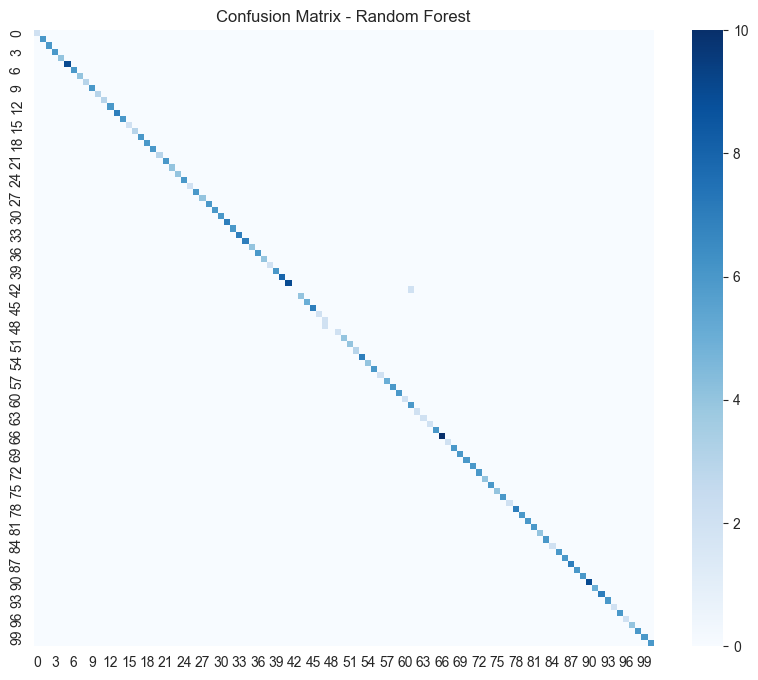

In [30]:


# ==============================
# 1️⃣ Import Required Libraries
# ==============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

# Sklearn Libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder


# ==============================
# 2️⃣ Load Dataset
# ==============================

# Load one-hot encoded training dataset
data = pd.read_csv("../datasets/training.csv")

print("Dataset Loaded Successfully")
print("Dataset Shape:", data.shape)


# ==============================
# 3️⃣ Data Preprocessing
# ==============================

# Separate features (X) and target label (y)
X = data.drop("Disease", axis=1)
y = data["Disease"]

# Encode disease labels into numeric values
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Number of Diseases:", len(label_encoder.classes_))


# ==============================
# 4️⃣ Train-Test Split
# ==============================

# Split dataset into training and testing sets (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])
feature_columns = X.columns
joblib.dump(feature_columns, "feature_columns.pkl")

# =========================
# 5. Logistic Regression
# =========================

log_model = LogisticRegression(max_iter=500)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

print("Logistic Accuracy:", accuracy_score(y_test, log_pred))
print(classification_report(y_test, log_pred, zero_division=0))

# =========================
# 6. Random Forest
# =========================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred, zero_division=0))

# =========================
# 7. Confusion Matrix
# =========================

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix - Random Forest")

# =========================
# 8. Cross Validation
# =========================
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_model, X, y_encoded, cv=skf)

print("CV Scores:", cv_scores)
print("Average CV Accuracy:", cv_scores.mean())

# =========================
# 9. Feature Importance
# =========================

importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importances.head(10))

import joblib

joblib.dump(rf_model, "disease_prediction_model.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")
joblib.dump(feature_columns, "feature_columns.pkl")

print("Model Saved Successfully")

In [31]:
import joblib
import pandas as pd

# Load datasets
description_df = pd.read_csv("../datasets/Description_df.csv")
precaution_df = pd.read_csv("../datasets/Precaution_df.csv")
workout_df = pd.read_csv("../datasets/Workouts_df.csv")
medication_df = pd.read_csv("../datasets/Medications_df.csv")
diet_df = pd.read_csv("../datasets/Diets_df.csv")
doctor_df = pd.read_csv("../datasets/doctors.csv")
# Load trained model
model = joblib.load("disease_prediction_model.pkl")
label_encoder = joblib.load("label_encoder.pkl")

def predict_and_recommend(symptom_list):

    # # Create empty input vector
    feature_columns = joblib.load("feature_columns.pkl")
    # input_data = [0] * len(feature_columns)
    #
    # for symptom in symptom_list:
    #     if symptom in X.columns:
    #         index = X.columns.get_loc(symptom)
    #         input_data[index] = 1
    input_data = [0] * len(feature_columns)

    for symptom in symptom_list:
        if symptom in feature_columns:
            index = feature_columns.get_loc(symptom)
            input_data[index] = 1


    # Convert to DataFrame
    input_df = pd.DataFrame([input_data], columns=feature_columns)

    # ===============================
    # Model Prediction (CLEAN VERSION)
    # ===============================

    prediction = model.predict(input_df)[0]
    probabilities = model.predict_proba(input_df)[0]

    # Main predicted disease
    disease = label_encoder.inverse_transform([prediction])[0]
    confidence = float(round(max(probabilities) * 100, 2))

    # ===============================
    # Top 3 Predictions (CORRECT)
    # ===============================

    top3_idx = np.argsort(probabilities)[::-1][:3]

    top3 = []
    for i in top3_idx:
        encoded_label = model.classes_[i]  # Correct mapping
        disease_name = label_encoder.inverse_transform([encoded_label])[0]
        prob = float(round(probabilities[i] * 100, 2))
        top3.append((disease_name, prob))



    # ===============================
    # Fetch Description
    # ===============================
    desc_row = description_df[description_df['Disease'] == disease]
    description = desc_row['Description'].values[0] if len(desc_row) > 0 else "No description available."
        # Clean formatting
    if description:
        description = description.replace(f"{disease},", "")
        description = description.replace('"', '').strip()

    # ===============================
    # medication
    med_row = medication_df[medication_df['Disease'] == disease]
    medication = med_row['Medication'].values[0] if len(med_row) > 0 else "No Medication available."
        # Clean formatting
    if medication:
        medication = medication.replace(f"{disease},", "")
        medication = medication.replace('"', '').strip()
    import ast

    med_row = medication_df[medication_df['Disease'] == disease]
    medication = []

    if len(med_row) > 0:
        med_str = med_row['Medication'].values[0]
        if med_str:
            try:
                medication = ast.literal_eval(med_str)
            except:
                medication = [med_str]

    # Fetch Precautions
    # ===============================
    precaution_row = precaution_df[precaution_df['Disease'] == disease]

    precautions = []
    if len(precaution_row) > 0:
        precautions = precaution_row[
            ['Precaution_1', 'Precaution_2', 'Precaution_3', 'Precaution_4']
        ].values.flatten().tolist()
    # ===============================
    # Fetch Workouts
    # ===============================
    workout_row = workout_df[workout_df['Disease'] == disease]
    workout_details = {}

    if len(workout_row) > 0:
        row = workout_row.iloc[0]

        exercises = [
            row['Exercise_1'],
            row['Exercise_2'],
            row['Exercise_3'],
            row['Exercise_4']
        ]

        # Remove NaN exercises
        exercises = [e for e in exercises if pd.notna(e)]

        workout_details = {
            "Exercises": exercises,
            "Intensity": row['Intensity'] if pd.notna(row['Intensity']) else "Not specified",
            "Duration": row['Duration'] if pd.notna(row['Duration']) else "Not specified",
            "Frequency": row['Frequency'] if pd.notna(row['Frequency']) else "Not specified",
            "Notes": row['Notes'] if pd.notna(row['Notes']) else "No additional notes"
        }

    # =====================================
    # Fetch Diets
    # =====================================
    diet_row = diet_df[diet_df['Disease'] == disease]
    diets = []
    if len(diet_row) > 0:
        diets = [d for d in diet_row.iloc[0][['Diet_1','Diet_2','Diet_3','Diet_4']] if pd.notna(d)]

    # =====================================
    # Fetch Doctor / Specialist
    # =====================================
    doctor_row = doctor_df[doctor_df['Disease'] == disease]
    doctor = doctor_row['Specialization'].values[0] if len(doctor_row) > 0 else "General Physician"



    return {
        "Disease": disease,
        "Confidence": confidence,
        "Top_3_Predictions": top3,
        "Description": description,
        "Medication": medication,
        "Precautions": precautions,
        "Workout": workout_details,
        "Diets": diets,
        "Doctor": doctor
    }

In [32]:
# Clean column names
description_df.columns = description_df.columns.str.strip()
precaution_df.columns = precaution_df.columns.str.strip()
workout_df.columns = workout_df.columns.str.strip()

# Remove unwanted column
if 'Unnamed: 5' in precaution_df.columns:
    precaution_df.drop(columns=['Unnamed: 5'], inplace=True)

In [33]:
test_symptoms = ["watery_diarrhea","dehydration","leg_cramps","nausea","vomiting"]
print(test_symptoms)

result = predict_and_recommend(test_symptoms)


['watery_diarrhea', 'dehydration', 'leg_cramps', 'nausea', 'vomiting']


In [34]:
print(result)

{'Disease': 'Cholera', 'Confidence': 100.0, 'Top_3_Predictions': [('Cholera', 100.0), ('Varicose veins', 0.0), ('Urinary tract infection', 0.0)], 'Description': 'Cholera is a serious diarrheal disease caused by bacteria from unsafe water or food, leading to severe watery diarrhea and dehydration. Quick rehydration and treatment can save lives.', 'Medication': ['Oral Rehydration Salts (ORS)', 'IV fluids', 'Azithromycin', 'Doxycycline', 'Zinc supplements'], 'Precautions': ['Maintain hydration', 'Use oral rehydration solution', 'Rest adequately', 'Follow medical treatment'], 'Workout': {'Exercises': [], 'Intensity': 'Not specified', 'Duration': 'Not specified', 'Frequency': 'Not specified', 'Notes': 'Hydration_priority'}, 'Diets': ['Oral rehydration salts (ORS)', 'Electrolyte replacement', 'Soft easily digestible foods', 'Avoid fatty or spicy meals'], 'Doctor': 'Infectious Disease Specialist'}


In [39]:

joblib.dump(label_encoder, "label_encoder.pkl")

['label_encoder.pkl']

In [40]:

joblib.dump(model, "disease_prediction_model.pkl")

['disease_prediction_model.pkl']

In [41]:
joblib.dump(X.columns, "feature_columns.pkl")

['feature_columns.pkl']